## LAES optimisation

In [1]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

#import optimization class
from cryoevap.optimize import Sensibility_jax

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

# Import JAX library
import jax
import jax.numpy as jnp

# Import pandas for data handling
import pandas as pd

# Set JAX to use 64-bit precision
jax.config.update("jax_enable_x64", True)


#### Setup tank and cryogen properties

In [15]:
# LNG tank properties
Q_roof = 0              # Roof heat ingress / W
T_air  = 18.08 + 273.15  # Temperature of the environment K

V_tank = 4831.0 # Tank volume / m^3

a   = 0.5
d_i = ((4 * V_tank)/(np.pi * a))**(1/3) # internal diameter / m

# Thickness of the in % of the internal diameter
ST  = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 8.72e-2 # W/m2/K
U_V = 8.72e-2 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.05

# Specify tank operating pressure
P = 101325*3 # Pa

# # Initialise cryogen
cryogen = Cryogen(name = "nitrogen")
cryogen.set_coolprops(P)

In [26]:
# Calculate q_b from thermal aspect ratio
eta_w = 0.9
H   = V_tank / (0.25 * np.pi * d_i**2)
A_L = np.pi * H * LF * d_o
A_V = np.pi * H * (1 - LF) * d_o
Q_L_wall = U_L * A_L * (T_air - cryogen.T_sat)
Q_V_wall = U_V * A_V * (T_air - cryogen.T_sat) * eta_w

rq1 = 0.3
q_b_1 = (1/rq1 - 1) * (Q_L_wall + Q_V_wall) / (np.pi * (d_o/2)**2)

rq2 = 0.7
q_b_2 = (1/rq2 - 1) * (Q_L_wall + Q_V_wall) / (np.pi * (d_o/2)**2)

print("Bottom heat flux ingress for r_q = 0.3: ", q_b_1, " W/m^2")
print("Bottom heat flux ingress for r_q = 0.7: ", q_b_2, " W/m^2")

Bottom heat flux ingress for r_q = 0.3:  73.35744324121222  W/m^2
Bottom heat flux ingress for r_q = 0.7:  13.473816105528778  W/m^2


In [27]:
# Set fixed bottom heat ingress
# q_b_fixed = 80.65265859116704 # 0.3
q_b_fixed = 14.813753618785782 # 0.7

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)
large_tank.set_HeatTransProps(U_L, U_V, T_air, q_b_fixed = q_b_fixed, Q_roof = 0, eta_w = 0.90)

# # Set cryogen
large_tank.cryogen = cryogen

# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))
# comparison of heat flux
print("q_b used: ", q_b_fixed, " q_b free: ", U_L*(T_air - cryogen.T_sat))
print("Q_b used: ", large_tank.Q_b, " Q_b free: ", U_L*(T_air - cryogen.T_sat)*(np.pi*((d_i**2)/4)))

The initial evaporation rate of nitrogen is 384.3 kg/h
q_b used:  14.813753618785782  q_b free:  17.716951564175947
Q_b used:  6200.210483811771  Q_b free:  7415.327111292465


#### Simulation setup and execution

In [28]:
# Define vertical spacing
dz = 0.1

# Calculate number of nodes
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 12 hours
evap_time = 3600 * 12

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 1200.0

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6

In [29]:
opti = Sensibility_jax(large_tank)
# Simulate the evaporation
large_tank.evaporate(evap_time)

In [30]:
# Define time of simulation
opti.time = evap_time

BOR Base en el óptimo: 0.050379 %/día
Parámetro: eta_w | Valor: 0.9000 | Gradiente: 3.75e-02 | Sensibilidad: 0.6697
Parámetro: U_V   | Valor: 0.0872 | Gradiente: 3.62e-01 | Sensibilidad: 0.6267
Parámetro: U_L   | Valor: 0.0872 | Gradiente: 2.15e-02 | Sensibilidad: 0.0372
Parámetro: eta   | Valor: 0.7000 | Gradiente: 1.13e-03 | Sensibilidad: -1.0447


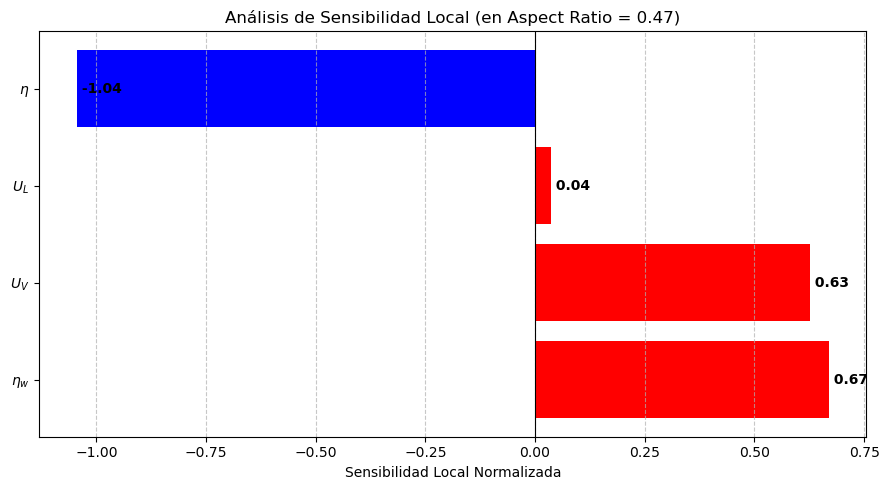

In [31]:
optimal_aspect_ratio  = 0.4677677677677678
thermal_aspect_ratio  = 0.7
Q_l = np.mean(large_tank.data['Q_L'])
Q_v = np.mean(large_tank.data['Q_Vw'])
At  = large_tank.A_T

bor_base = opti.objective_function(optimal_aspect_ratio, opti.params)
print(f"BOR Base en el óptimo: {bor_base:.6f} %/día")

params_to_analyze = ['eta_w', 'U_V', 'U_L', 'q_b_fixed']
results = {}

for param in params_to_analyze:
    val_param = opti.params[param]
    
    grad = float(opti.calculate_sensibility_param(param, optimal_aspect_ratio))
    
    if param == 'q_b_fixed':
        dqdeta= - (Q_l + Q_v) / (At * thermal_aspect_ratio**2)
        val_param = thermal_aspect_ratio
        param = "eta"
        sensitivity_norm = grad * dqdeta * (float(val_param) / float(bor_base))
    else:
        sensitivity_norm = grad * (float(val_param) / float(bor_base))
    
    
    results[param] = {
        'grad': grad,
        'sensitivity': sensitivity_norm,
        'value': float(val_param)
    }
    
    print(f"Parámetro: {param:5s} | Valor: {val_param:.4f} | "
          f"Gradiente: {grad:.2e} | Sensibilidad: {sensitivity_norm:.4f}")


params_names = [r'$\eta_w$', r'$U_V$', r'$U_L$', r'$\eta$']
params_to_analyze = ['eta_w', 'U_V', 'U_L', 'eta']
sensitivities = [results[p]['sensitivity'] for p in params_to_analyze]

plt.figure(figsize=(9, 5))
colors = ['red' if s > 0 else 'blue' for s in sensitivities]
plt.barh(params_names, sensitivities, color=colors)
plt.axvline(0, color='black', linewidth=0.8)

plt.xlabel('Sensibilidad Local Normalizada')
plt.title(f'Análisis de Sensibilidad Local (en Aspect Ratio = {optimal_aspect_ratio:.2f})')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, v in enumerate(sensitivities):
    plt.text(v, i, f" {v:.2f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
sensitivities

[0.669669224920049,
 0.6266966437797238,
 0.03716294296552488,
 np.float64(-1.044701619992751)]

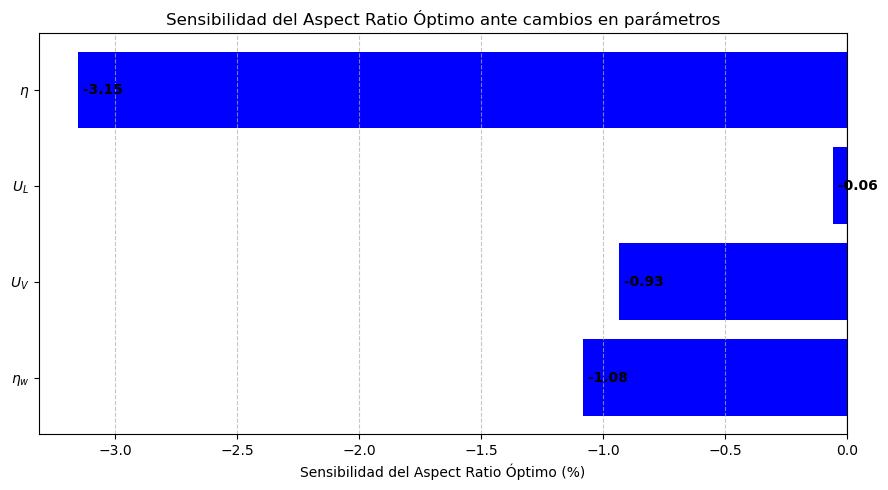

In [33]:
# Sensibilidad en el óptimo
params_to_analyze = ['eta_w', 'U_V', 'U_L', 'q_b_fixed']
grad_fun = jax.grad(opti.objective_function, argnums=0, allow_int=True) 
hess_fun = jax.jacfwd(grad_fun, argnums=0)
mixed_grad_fun = jax.jacfwd(grad_fun, argnums=1) 

H_xx     = hess_fun(optimal_aspect_ratio, opti.params)
grads_xp = mixed_grad_fun(optimal_aspect_ratio, opti.params)

sens_opt_list = []
for param in params_to_analyze:
    d2f_dxdp = grads_xp[param]
    dx_dp    = - d2f_dxdp / H_xx

    if param == 'q_b_fixed':
        param = "eta"
        dqdeta= - (Q_l + Q_v) / (At * thermal_aspect_ratio**2)
        sens_opt = dx_dp * dqdeta * (thermal_aspect_ratio / optimal_aspect_ratio)

    else:
        sens_opt = dx_dp * (opti.params[param] / optimal_aspect_ratio)

    sens_opt_list.append(float(sens_opt))

plt.figure(figsize=(9, 5))
colors_opt = ['red' if s > 0 else 'blue' for s in sens_opt_list]
plt.barh(params_names, sens_opt_list, color=colors_opt)
plt.axvline(0, color='black', linewidth=0.8)

plt.xlabel('Sensibilidad del Aspect Ratio Óptimo (%)')
plt.title('Sensibilidad del Aspect Ratio Óptimo ante cambios en parámetros')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, v in enumerate(sens_opt_list):
    plt.text(v, i, f" {v:.2f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:
sens_opt_list

[-1.080961828021868,
 -0.9337561066605194,
 -0.056267757090271216,
 -3.153839100538684]